# Šahrestānīhā ī Ērānšahr — Person Relations Network

Builds a NetworkX graph from the XML file and exports:
1. A matplotlib figure (static, for inspection)
2. An interactive HTML file for the site

In [1]:
import xml.etree.ElementTree as ET
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json, os

# Config 
XML_PATH  = 'sahrestaniha_i_eran_sahr_multilingual.xml'  # adjust path if needed
OUT_HTML  = 'network.html'
OUT_PNG   = 'network_graph.png'
XML_NS    = 'http://www.w3.org/XML/1998/namespace'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Parse XML 
def lang(seg): return seg.get(f'{{{XML_NS}}}lang','') or seg.get('xml:lang','')
def full_text(el): return ''.join(el.itertext()).strip()
def norm(s): return ' '.join(s.split())
def xid(el): return el.get(f'{{{XML_NS}}}id') or el.get('xml:id','')

tree = ET.parse(XML_PATH)
root = tree.getroot()

persons = {}
for s in root.iter('s'):
    pal = next((seg for seg in s if lang(seg)=='pal'), None)
    if pal is None: continue
    for pn in pal.iter('persName'):
        pid = xid(pn)
        if not pid: continue
        forename = next((norm(full_text(c)) for c in pn if c.tag in ('forename','foreName')), '') or norm(full_text(pn))[:25]
        role     = next((c.get('type','') for c in pn if c.tag=='roleName'), '')
        epithet  = next((c.get('subtype','') for c in pn if c.tag=='addName' and c.get('type')=='epithet'), '')
        if pid not in persons:
            persons[pid] = {'name': forename or pid, 'role': role, 'epithet': epithet, 'count': 0}
        persons[pid]['count'] += 1

edges = []
for s in root.iter('s'):
    pal = next((seg for seg in s if lang(seg)=='pal'), None)
    if pal is None: continue
    sn = s.get('n','?')
    for rel in pal.iter('relation'):
        rtype  = rel.get('type','')
        rsub   = rel.get('subtype','') or rtype
        active = (rel.get('active','') or '').strip()
        passive= (rel.get('passive','') or '').strip()
        mutual = (rel.get('mutual','') or '').strip()
        if active and passive:
            for a in active.split():
                for p in passive.split():
                    a,p = a.lstrip('#'), p.lstrip('#')
                    if a and p: edges.append((a, p, rtype, rsub, sn))
        if mutual:
            parts = [m.lstrip('#') for m in mutual.split()]
            for i in range(len(parts)):
                for j in range(i+1, len(parts)):
                    edges.append((parts[i], parts[j], rtype, rsub, sn))

print(f'Persons found: {len(persons)}')
print(f'Relations found: {len(edges)}')

Persons found: 70
Relations found: 35


In [3]:
# Build NetworkX graph
G = nx.DiGraph()
for pid, d in persons.items():
    G.add_node(pid, **d)
for a, p, rtype, rsub, sn in edges:
    if a and p:
        G.add_edge(a, p, type=rtype, subtype=rsub, sentence=sn)

# Keep only connected nodes
G = G.subgraph([n for n in G.nodes if G.degree(n) > 0]).copy()
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Connected components: {nx.number_weakly_connected_components(G)}')

Graph: 50 nodes, 34 edges
Connected components: 17


In [4]:
# Colour helpers
BG = '#050505'
EDGE_C = {
    'son-of':     '#c9a84c',
    'daughter-of':'#c9a84c',
    'father-of':  '#5ec8c8',
    'wife-of':    '#b07070',
    'member-of':  '#7a5a9a',
    'nephew-of':  '#7a5a9a',
    'built':      '#5a8a5a',
    'parent':     '#c9a84c',
    'spouse':     '#b07070',
    'family':     '#7a5a9a',
}

def node_color(n):
    d = G.nodes[n]
    if d.get('epithet') == 'pejorative': return '#a05858'
    if d.get('role') in ('king','khan'):  return '#5ec8c8'
    return '#666666'

def node_size(n): return max(120, G.nodes[n].get('count',1)*80+80)

def edge_color(u, v):
    sub = G[u][v].get('subtype','')
    typ = G[u][v].get('type','')
    return EDGE_C.get(sub) or EDGE_C.get(typ) or '#3a3a3a'

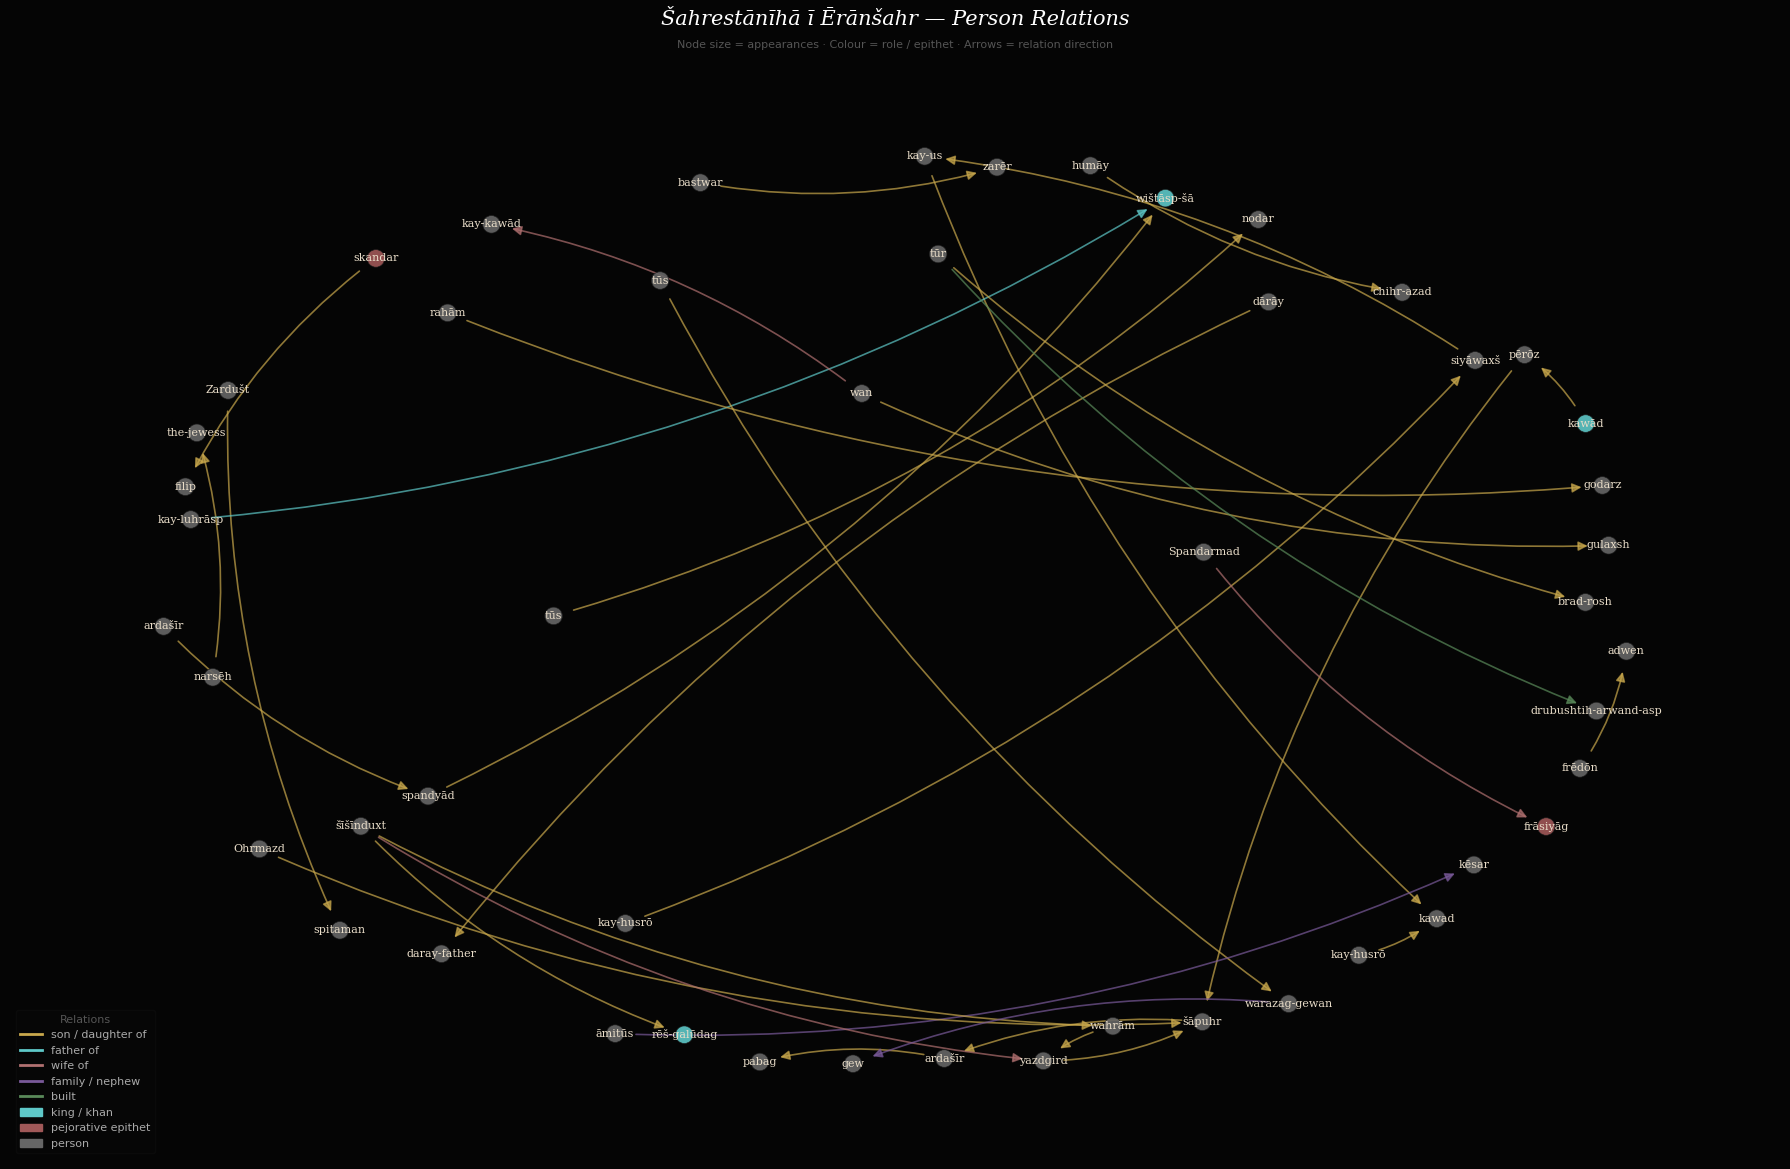

Saved network_graph.png


In [5]:
# Matplotlib figure
pos = nx.spring_layout(G, k=2.8, seed=42, iterations=120)

fig, ax = plt.subplots(figsize=(18, 12))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_axis_off()

nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color=[edge_color(u,v) for u,v in G.edges],
    arrows=True, arrowsize=14, arrowstyle='-|>',
    connectionstyle='arc3,rad=0.12', width=1.2, alpha=0.7,
    min_source_margin=15, min_target_margin=15)

nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=[node_color(n) for n in G.nodes],
    node_size=[node_size(n) for n in G.nodes],
    alpha=0.9, linewidths=0.5, edgecolors='#1a1a1a')

nx.draw_networkx_labels(G, pos, ax=ax,
    labels={n: G.nodes[n].get('name',n) for n in G.nodes},
    font_size=8, font_color='#e8dcc8', font_family='serif')

legend_elements = [
    Line2D([0],[0], color='#c9a84c', lw=2, label='son / daughter of'),
    Line2D([0],[0], color='#5ec8c8', lw=2, label='father of'),
    Line2D([0],[0], color='#b07070', lw=2, label='wife of'),
    Line2D([0],[0], color='#7a5a9a', lw=2, label='family / nephew'),
    Line2D([0],[0], color='#5a8a5a', lw=2, label='built'),
    mpatches.Patch(color='#5ec8c8', label='king / khan'),
    mpatches.Patch(color='#a05858', label='pejorative epithet'),
    mpatches.Patch(color='#666666', label='person'),
]
legend = ax.legend(handles=legend_elements, loc='lower left',
    framealpha=0.15, facecolor='#0d0d0d', edgecolor='#2a2a2a',
    labelcolor='#aaaaaa', fontsize=8, title='Relations', title_fontsize=8)
legend.get_title().set_color('#555555')

fig.text(0.5, 0.97, 'Šahrestānīhā ī Ērānšahr — Person Relations',
    ha='center', va='top', color='#ffffff', fontsize=15, fontstyle='italic', fontfamily='serif')
fig.text(0.5, 0.945, 'Node size = appearances · Colour = role / epithet · Arrows = relation direction',
    ha='center', va='top', color='#555555', fontsize=8)

plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig(OUT_PNG, dpi=180, bbox_inches='tight', facecolor=BG, edgecolor='none')
plt.show()
print(f'Saved {OUT_PNG}')

In [6]:
# Export interactive HTML for the site
# Serialise graph to JSON and embed in a self-contained D3 page

nodes_data = []
for n in G.nodes:
    d = G.nodes[n]
    nodes_data.append({
        'id':       n,
        'name':     d.get('name', n),
        'role':     d.get('role',''),
        'epithet':  d.get('epithet',''),
        'count':    d.get('count', 1),
    })

links_data = []
for u, v, d in G.edges(data=True):
    links_data.append({
        'source':   u,
        'target':   v,
        'type':     d.get('type',''),
        'subtype':  d.get('subtype',''),
        'sentence': d.get('sentence',''),
    })

graph_json = json.dumps({'nodes': nodes_data, 'links': links_data}, ensure_ascii=False)
print(f'Serialised: {len(nodes_data)} nodes, {len(links_data)} links')
print('Run the next cell to write the HTML file.')

Serialised: 50 nodes, 34 links
Run the next cell to write the HTML file.


In [7]:
# Write network.html
html = f'''<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>Relations — Šahrestānīhā ī Ērānšahr</title>
  <link rel="stylesheet" href="textstyle.css"/>
  <style>
    .network-main {{ max-width:1400px; margin:0 auto; padding:130px 40px 80px; }}
    .network-subtitle {{ font-size:0.82rem; color:#555; letter-spacing:0.06em;
      text-transform:uppercase; margin-top:0.4rem; margin-bottom:1.8rem; font-family:"lora",serif; }}
    .net-legend {{ display:flex; flex-wrap:wrap; gap:0.5rem 1.4rem;
      margin-bottom:1.6rem; align-items:center; }}
    .leg-item {{ display:flex; align-items:center; gap:0.45rem;
      font-family:"lora",serif; font-size:0.72rem; color:#888; }}
    .leg-line {{ width:24px; height:2px; border-radius:1px; }}
    .leg-dot  {{ width:10px; height:10px; border-radius:50%; flex-shrink:0; }}
    .net-controls {{ display:flex; gap:0.6rem; align-items:center;
      margin-bottom:1rem; flex-wrap:wrap; }}
    .ctrl-label {{ font-family:"lora",serif; font-size:0.7rem; letter-spacing:0.06em;
      text-transform:uppercase; color:#555; }}
    .ctrl-btn {{ background:none; border:0.5px solid #2a2a2a; border-radius:3px;
      color:#888; font-family:"lora",serif; font-size:0.68rem; letter-spacing:0.06em;
      text-transform:uppercase; padding:0.35em 0.9em; cursor:pointer;
      transition:color 0.15s, border-color 0.15s; }}
    .ctrl-btn:hover {{ color:#fff; border-color:#555; }}
    .ctrl-btn.active {{ color:#fff; border-color:#555; background:#111; }}
    .net-canvas {{ width:100%; height:72vh; min-height:500px;
      background:#050505; border:0.5px solid #1a1a1a;
      border-radius:4px; overflow:hidden; position:relative; }}
    #net-svg {{ width:100%; height:100%; cursor:grab; }}
    #net-svg:active {{ cursor:grabbing; }}
    .net-tip {{ position:absolute; background:#0d0d0d; border:0.5px solid #2a2a2a;
      border-radius:4px; padding:10px 14px; font-family:"lora",serif;
      pointer-events:none; opacity:0; transition:opacity 0.15s; z-index:100;
      max-width:240px; }}
    .net-tip.vis {{ opacity:1; }}
    .tip-name {{ font-size:1rem; color:#fff; margin-bottom:0.3rem; }}
    .tip-role {{ font-size:0.72rem; color:#5ec8c8; letter-spacing:0.05em;
      text-transform:uppercase; margin-bottom:0.2rem; }}
    .tip-s {{ font-size:0.7rem; color:#555; }}
    .tip-rel {{ font-size:0.72rem; color:#888; margin-top:0.4rem; line-height:1.5; }}
    .node text {{ font-family:"lora",serif; font-size:11px; fill:#aaa;
      pointer-events:none; user-select:none; font-style:italic; }}
  </style>
</head>
<body>
  <nav class="navbar">
    <ul class="nav-links-left">
      <li><a href="texts-static.html">Text</a></li>
      <li><a href="analysis.html" class="active">Analysis</a></li>
      <li><a href="glossary.html">Glossary</a></li>
    </ul>
    <ul class="nav-links">
      <li><a href="index.html">Home</a></li>
      <li><a href="index.html#about">About</a></li>
    </ul>
  </nav>
  <main class="network-main">
    <h1>Person Relations</h1>
    <p class="network-subtitle">Šahrestānīhā ī Ērānšahr — Relational Network</p>
    <div class="net-legend">
      <div class="leg-item"><div class="leg-line" style="background:#c9a84c"></div>son / daughter of</div>
      <div class="leg-item"><div class="leg-line" style="background:#5ec8c8"></div>father of</div>
      <div class="leg-item"><div class="leg-line" style="background:#b07070"></div>wife of</div>
      <div class="leg-item"><div class="leg-line" style="background:#7a5a9a"></div>family / nephew</div>
      <div class="leg-item"><div class="leg-line" style="background:#5a8a5a"></div>built</div>
      <div class="leg-item" style="margin-left:1rem"><div class="leg-dot" style="background:#5ec8c8"></div>king / khan</div>
      <div class="leg-item"><div class="leg-dot" style="background:#a05858"></div>pejorative</div>
      <div class="leg-item"><div class="leg-dot" style="background:#888"></div>person</div>
    </div>
    <div class="net-controls">
      <span class="ctrl-label">Filter:</span>
      <button class="ctrl-btn active" data-f="all">All</button>
      <button class="ctrl-btn" data-f="parent">Lineage</button>
      <button class="ctrl-btn" data-f="spouse">Spouse</button>
      <button class="ctrl-btn" data-f="family">Family</button>
      <button class="ctrl-btn" data-f="built">Built</button>
      <span class="ctrl-label" style="margin-left:1rem">Scroll to zoom · Drag to pan · Click node to highlight</span>
    </div>
    <div class="net-canvas" id="net-canvas">
      <svg id="net-svg"></svg>
      <div class="net-tip" id="net-tip">
        <div class="tip-name" id="tip-name"></div>
        <div class="tip-role" id="tip-role"></div>
        <div class="tip-s" id="tip-s"></div>
        <div class="tip-rel" id="tip-rel"></div>
      </div>
    </div>
  </main>
  <script src="https://cdnjs.cloudflare.com/ajax/libs/d3/7.8.5/d3.min.js"></script>
  <script>
  const RAW = {graph_json};
  const EDGE_C = {{'son-of':'#c9a84c','daughter-of':'#c9a84c','father-of':'#5ec8c8',
    'wife-of':'#b07070','member-of':'#7a5a9a','nephew-of':'#7a5a9a',
    'built':'#5a8a5a','parent':'#c9a84c','spouse':'#b07070','family':'#7a5a9a'}};
  function lc(d){{ return EDGE_C[d.subtype]||EDGE_C[d.type]||'#3a3a3a'; }}
  function nc(d){{
    if(d.epithet==='pejorative') return '#a05858';
    if(d.role==='king'||d.role==='khan') return '#5ec8c8';
    return '#888';
  }}
  function nr(d){{ return Math.max(5, Math.min(14, 5+d.count*1.5)); }}

  function build(filterType){{
    const svg = d3.select('#net-svg'); svg.selectAll('*').remove();
    const W = document.getElementById('net-svg').clientWidth;
    const H = document.getElementById('net-svg').clientHeight;
    const links = filterType ? RAW.links.filter(l=>l.type===filterType) : RAW.links;
    const used = new Set(); links.forEach(l=>{{used.add(l.source);used.add(l.target);}});
    const nodes = filterType ? RAW.nodes.filter(n=>used.has(n.id)) : RAW.nodes;
    const sn = {{}}; nodes.forEach(n=>sn[n.id]=n);
    const sl = links.filter(l=>sn[l.source]&&sn[l.target]).map(l=>({{...l,source:sn[l.source],target:sn[l.target]}}));
    const zoom=d3.zoom().scaleExtent([0.2,4]).on('zoom',e=>g.attr('transform',e.transform));
    svg.call(zoom);
    const g=svg.append('g');
    const mtypes=[...new Set(sl.map(l=>l.subtype||l.type))];
    svg.append('defs').selectAll('marker').data(mtypes).join('marker')
      .attr('id',d=>'arr-'+d).attr('viewBox','0 -4 8 8')
      .attr('refX',18).attr('refY',0).attr('markerWidth',6).attr('markerHeight',6).attr('orient','auto')
      .append('path').attr('d','M0,-4L8,0L0,4')
      .attr('fill',d=>EDGE_C[d]||'#3a3a3a').attr('fill-opacity',0.6);
    const link=g.append('g').selectAll('line').data(sl).join('line')
      .attr('stroke',lc).attr('stroke-width',1.2).attr('stroke-opacity',0.6)
      .attr('marker-end',d=>'url(#arr-'+(d.subtype||d.type)+')');
    const node=g.append('g').selectAll('g').data(nodes).join('g').attr('class','node')
      .call(d3.drag()
        .on('start',(e,d)=>{{if(!e.active)sim.alphaTarget(0.3).restart();d.fx=d.x;d.fy=d.y;}})
        .on('drag',(e,d)=>{{d.fx=e.x;d.fy=e.y;}})
        .on('end',(e,d)=>{{if(!e.active)sim.alphaTarget(0);d.fx=null;d.fy=null;}}));
    node.append('circle').attr('r',nr).attr('fill',nc).attr('fill-opacity',0.85)
      .attr('stroke',d=>nc(d)).attr('stroke-width',0.5).attr('stroke-opacity',0.3);
    node.append('text').attr('dy',d=>-nr(d)-4).attr('text-anchor','middle').text(d=>d.name||d.id);
    const tip=document.getElementById('net-tip');
    const canv=document.getElementById('net-canvas');
    node.on('mousemove',(e,d)=>{{
      const r=canv.getBoundingClientRect();
      let x=e.clientX-r.left+14, y=e.clientY-r.top-10;
      if(x+250>r.width) x=e.clientX-r.left-260;
      tip.style.left=x+'px'; tip.style.top=y+'px';
      document.getElementById('tip-name').textContent=d.name||d.id;
      document.getElementById('tip-role').textContent=d.role?d.role.toUpperCase():'';
      document.getElementById('tip-s').textContent='';
      const rels=sl.filter(l=>l.source.id===d.id||l.target.id===d.id);
      document.getElementById('tip-rel').innerHTML=rels.map(l=>{{
        const o=l.source.id===d.id?l.target:l.source;
        const dir=l.source.id===d.id?'→':'←';
        return '<span style="color:'+lc(l)+'">'+(l.subtype||l.type)+'</span> '+dir+' '+(o.name||o.id);
      }}).join('<br>');
      tip.classList.add('vis');
    }}).on('mouseleave',()=>tip.classList.remove('vis'))
    .on('click',(e,d)=>{{
      e.stopPropagation();
      const conn=new Set([d.id]);
      sl.forEach(l=>{{if(l.source.id===d.id)conn.add(l.target.id);if(l.target.id===d.id)conn.add(l.source.id);}});
      node.select('circle').attr('fill-opacity',n=>conn.has(n.id)?1:0.1).attr('stroke-opacity',n=>conn.has(n.id)?0.8:0.05);
      node.select('text').attr('fill',n=>conn.has(n.id)?'#fff':'#222');
      link.attr('stroke-opacity',l=>conn.has(l.source.id)&&conn.has(l.target.id)?0.9:0.04);
    }});
    svg.on('click',()=>{{
      node.select('circle').attr('fill-opacity',0.85).attr('stroke-opacity',0.3);
      node.select('text').attr('fill','#aaa');
      link.attr('stroke-opacity',0.6);
    }});
    const sim=d3.forceSimulation(nodes)
      .force('link',d3.forceLink(sl).id(d=>d.id).distance(90).strength(0.5))
      .force('charge',d3.forceManyBody().strength(-220))
      .force('center',d3.forceCenter(W/2,H/2))
      .force('collision',d3.forceCollide().radius(d=>nr(d)+18))
      .on('tick',()=>{{
        link.attr('x1',d=>d.source.x).attr('y1',d=>d.source.y)
            .attr('x2',d=>d.target.x).attr('y2',d=>d.target.y);
        node.attr('transform',d=>`translate(${{d.x}},${{d.y}})`);
      }});
  }}
  document.querySelectorAll('.ctrl-btn').forEach(b=>b.addEventListener('click',()=>{{
    document.querySelectorAll('.ctrl-btn').forEach(x=>x.classList.remove('active'));
    b.classList.add('active');
    build(b.dataset.f==='all'?null:b.dataset.f);
  }}));
  build(null);
  </script>
</body>
</html>'''

with open(OUT_HTML, 'w', encoding='utf-8') as f:
    f.write(html)
print(f'Written {OUT_HTML} — place in your site folder alongside textstyle.css')

Written network.html — place in your site folder alongside textstyle.css
